# Fixation Generation Check

This notebook will simulate fixations then confirm that their distributions match empirical distributions.

In [1]:
from ast import literal_eval
import pandas as pd

df_raw = pd.read_csv('1ms_trial_data.csv')

to_drop = pd.read_csv("dropped_trials.csv").rename(columns={"parcode": "sub_id"})

df = df_raw.loc[
    ~df_raw.set_index(["sub_id", "trial"]).index.isin(
        to_drop.set_index(["sub_id", "trial"]).index
    )
    & (~df_raw["hidden"])
]

df['RT'] = (df['RT']*1000).astype(int) # RT unit scaling
df['fixation'] = df['fixation'].apply(literal_eval) # String to list as a result of csv saving
df['choice'] = df['choice'].replace({"left": 0, "right": 1}) # Map choice to 0 or 1

/var/folders/59/03h51wmn6xn1jhvb7kj9fjc40000gn/T/ipykernel_29714/3236189508.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['RT'] = (df['RT']*1000).astype(int) # RT unit scaling
/var/folders/59/03h51wmn6xn1jhvb7kj9fjc40000gn/T/ipykernel_29714/3236189508.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['fixation'] = df['fixation'].apply(literal_eval) # String to list as a result of csv saving
/var/folders/59/03h51wmn6xn1jhvb7kj9fjc40000gn/T/ipykernel_29714/3236189508.py:17: FutureWarning: Down

In [2]:
from simulation import get_corrected_empirical_distributions
import numpy as np

value_diffs = np.unique(df['avgWTP_left'] - df['avgWTP_right'])
legend = {
    "left": {1},
    "right": {2},
    "transition": {0}, 
    "blank_fixation": {4}
}
fixation_col = 'fixation'
left_value_col = 'avgWTP_left'
right_value_col = 'avgWTP_right'

empirical_distributions = get_corrected_empirical_distributions(
    df,
    value_diffs=value_diffs,
    legend=legend,
    fixation_col=fixation_col,
    left_value_col=left_value_col,
    right_value_col=right_value_col,
    cutoff=0.9
)

In [3]:
from simulation import generate_fixations

dt = 0.001
seed = 42

trials = df.loc[
    (df['sub_id'] == 304) & (df['trial'] % 2 == 1),
    ['avgWTP_left', 'avgWTP_right']
].copy()
trials['fixation'] = None

rng = np.random.default_rng(seed)
trials_dict = []
for idx, r in trials.iterrows():
    fx = generate_fixations(
        dt, 
        r.avgWTP_left - r.avgWTP_right, 
        empirical_distributions,
        rng=rng
    )
    if fx is not None:
        trials_dict.append({
            "avgWTP_left": r.avgWTP_left,
            "avgWTP_right": r.avgWTP_right,
            "fixation": fx
        })

In [4]:
from simulation import simulate
import pyddm

model_conditions = {'drift_rate': 0.8, 'theta': 0.5, 'noise': 0.6}

results_df = simulate(dt, model_conditions, trials_dict, seed=seed, save_results=False)
results_df = results_df.drop(columns = ['trajectory'])

sample = pyddm.Sample.from_pandas_dataframe(
    results_df,
    choice_column_name="choice",
    rt_column_name="RT",
    choice_names=("left", "right")
)

print(f'Average RT: {results_df["RT"].mean():.2f} seconds (out of {len(results_df)} trials)')
results_df.head()

Average RT: 1.38 seconds (out of 100 trials)


,avgWTP_left,avgWTP_right,fixation,RT,choice
0,1.00,1.00,"(0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",1.659,0
1,4.25,3.00,"(0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",3.462,0
2,3.25,3.75,"(0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",1.253,0
3,3.00,2.75,"(0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",2.663,1
4,1.00,4.00,"(0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0.837,1


In [5]:
simulated_empirical_distributions = get_corrected_empirical_distributions(
    results_df,
    value_diffs=value_diffs,
    legend=legend,
    fixation_col=fixation_col,
    left_value_col=left_value_col,
    right_value_col=right_value_col,
    cutoff=1
)

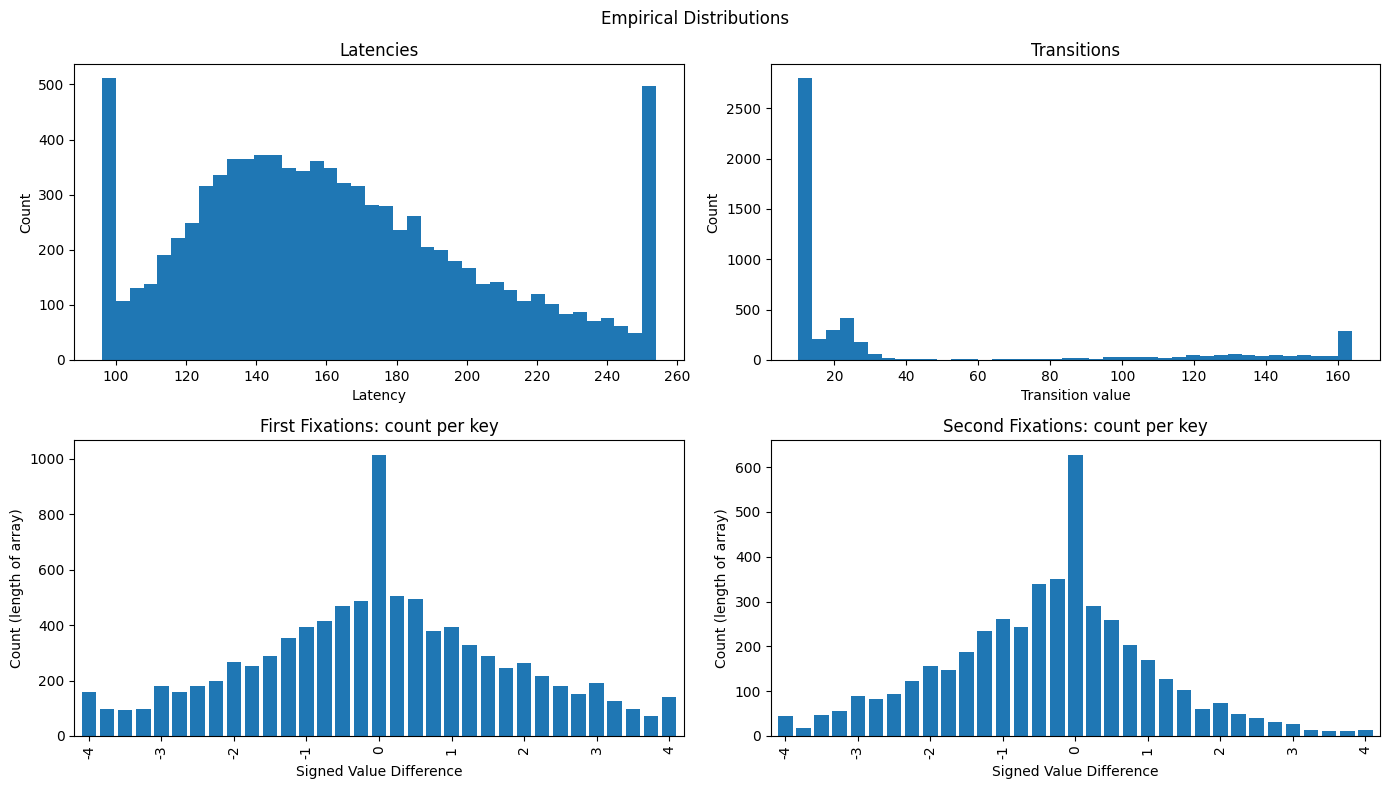

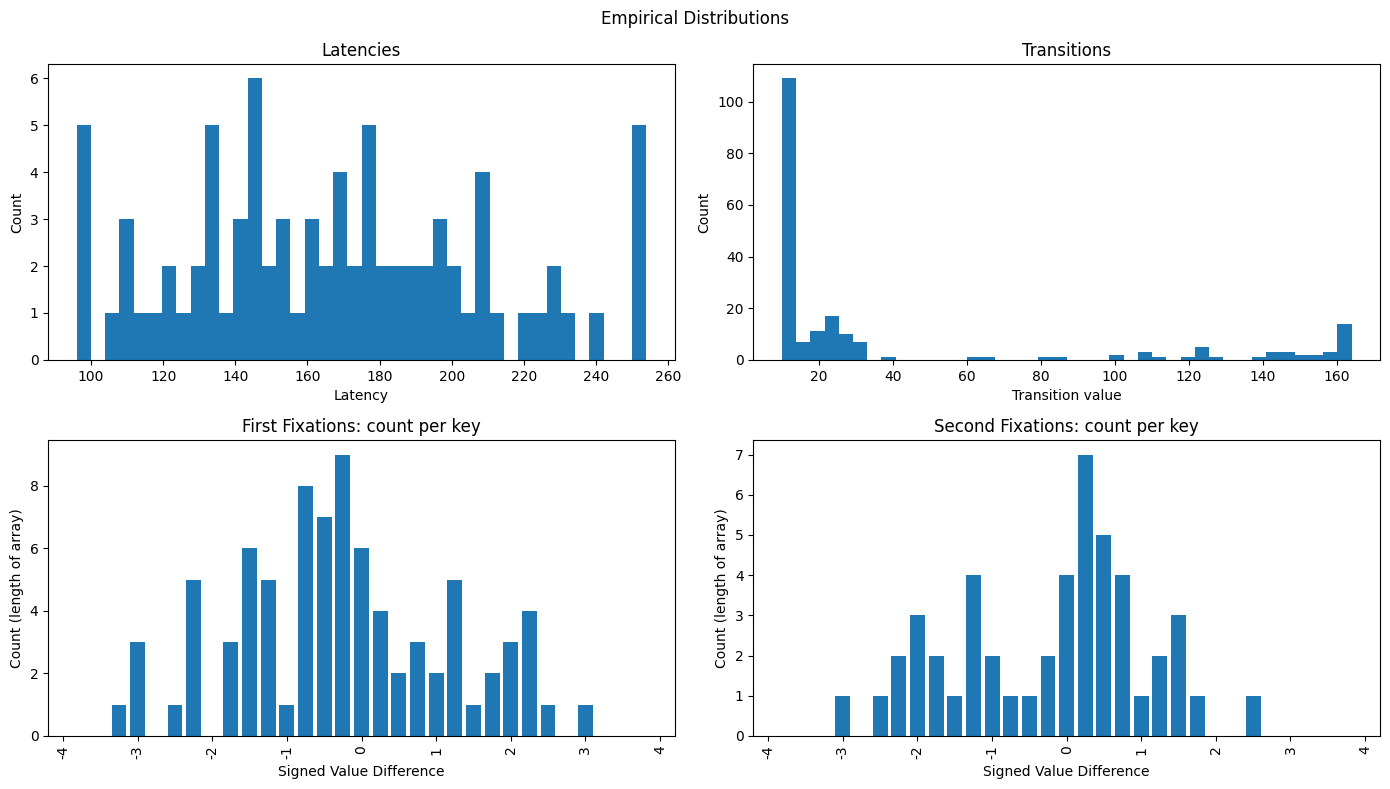

In [6]:
import numpy as np
import matplotlib.pyplot as plt

def _as_1d_float_array(x):
    if x is None:
        return np.array([], dtype=float)
    return np.asarray(x, dtype=float).ravel()

def _fix_lengths_per_key(fix_map):
    """
    fix_map: dict where keys are floats in [-4.0, 4.0] step 0.25
             and values are array-like (whose lengths we count).
    Returns (keys_sorted_float, lengths_per_key_as_float).
    """
    if not isinstance(fix_map, dict) or not fix_map:
        return np.array([], dtype=float), np.array([], dtype=float)
    # Sort keys numerically to keep the x-axis ordered
    keys = sorted(fix_map.keys(), key=float)
    lengths = [len(_as_1d_float_array(fix_map[k])) for k in keys]
    return np.array(keys, dtype=float), np.array(lengths, dtype=float)

def _set_sparse_xticks(ax, xs, every=4, rotation=0):
    """Show only every Nth tick to reduce clutter."""
    if xs.size == 0:
        return
    idx = np.arange(xs.size)
    show = (idx % every) == 0
    ax.set_xticks(xs[show])
    ax.set_xticklabels([f"{v:g}" for v in xs[show]], rotation=rotation)

def plot_empirical_distributions(ed, *, tick_every=4):
    """
    ed: dict with keys:
        - 'latencies': np.ndarray of floats
        - 'transitions': np.ndarray of floats
        - 'fixations': dict {1: dict{float_key: array}, 2: dict{float_key: array}}

    Creates a 2x2 figure:
      (1,1) histogram of ed['latencies']
      (1,2) histogram of ed['transitions']
      (2,1) bar chart: keys of fixations[1] on x, lengths of arrays as heights
      (2,2) bar chart: keys of fixations[2] on x, lengths of arrays as heights
    """
    latencies = _as_1d_float_array(ed.get('latencies', np.array([])))
    transitions = _as_1d_float_array(ed.get('transitions', np.array([])))

    fix = ed.get('fixations', {}) if isinstance(ed, dict) else {}
    fix1 = fix.get(1, {})
    fix2 = fix.get(2, {})

    keys1, lens1 = _fix_lengths_per_key(fix1)
    keys2, lens2 = _fix_lengths_per_key(fix2)

    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    ax11, ax12, ax21, ax22 = axes.ravel()

    # Top row: true histograms (continuous/binning)
    ax11.hist(latencies, bins=40)
    ax11.set_title("Latencies")
    ax11.set_xlabel("Latency")
    ax11.set_ylabel("Count")

    ax12.hist(transitions, bins=40)
    ax12.set_title("Transitions")
    ax12.set_xlabel("Transition value")
    ax12.set_ylabel("Count")

    # Bottom row: fixed-bin “histograms” → bar charts at the exact key values
    if keys1.size:
        # width smaller than the 0.25 spacing to leave a small gap
        ax21.bar(keys1, lens1, width=0.20, align='center')
        ax21.set_xlim(keys1.min() - 0.2, keys1.max() + 0.2)
        _set_sparse_xticks(ax21, keys1, every=tick_every, rotation=90)
    ax21.set_title("First Fixations: count per key")
    ax21.set_xlabel("Signed Value Difference")
    ax21.set_ylabel("Count (length of array)")

    if keys2.size:
        ax22.bar(keys2, lens2, width=0.20, align='center')
        ax22.set_xlim(keys2.min() - 0.2, keys2.max() + 0.2)
        _set_sparse_xticks(ax22, keys2, every=tick_every, rotation=90)
    ax22.set_title("Second Fixations: count per key")
    ax22.set_xlabel("Signed Value Difference")
    ax22.set_ylabel("Count (length of array)")

    fig.suptitle("Empirical Distributions", y=0.98)
    fig.tight_layout()
    return fig, axes

fig, axes = plot_empirical_distributions(empirical_distributions, tick_every=4)
plt.show()
fig, axes = plot_empirical_distributions(simulated_empirical_distributions, tick_every=4)
plt.show()